<a href="https://colab.research.google.com/github/UKD1211/Macroeconomic_impact_of_gold-_Econ_growth/blob/main/phase_2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_master = pd.read_excel("/content/Master_Dataset.xlsx")

In [ ]:
df_master

In [ ]:
df_master.info()

In [ ]:
df_master.duplicated().sum()

# **What is Gold Anomaly Detection?**

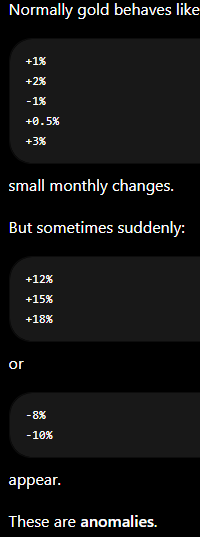

In [ ]:
df_master['Gold_Return_%'] = (
    df_master['Gold_Price[/10gm]']
    .pct_change()
    * 100
)

In [ ]:
df_master

In [ ]:
df_master['Gold_Return_%'].describe()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.histplot(
    data=df_master,
    x='Gold_Return_%',
    bins=35,
    kde=True,
    stat='density',
    alpha=0.7
)

plt.title(
    'Distribution of Monthly Gold Returns (2000–2026)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Monthly Return (%)',
    fontsize=12
)

plt.ylabel(
    'Density',
    fontsize=12
)

plt.grid(
    alpha=0.25,
    linestyle='--'
)

plt.tight_layout()

plt.show()

In [ ]:
mean_return = df_master['Gold_Return_%'].mean()
std_return = df_master['Gold_Return_%'].std()
upper_limit = mean_return + 2*std_return
lower_limit = mean_return - 2*std_return
print(f'Mean Return: {mean_return:.2f}%')
print(f'Standard Deviation: {std_return:.2f}%')
print(f'Upper Limit: {upper_limit:.2f}%')
print(f'Lower Limit: {lower_limit:.2f}%')

In [ ]:
gold_anomalies = df_master[
    (df_master['Gold_Return_%'] > upper_limit)
    |
    (df_master['Gold_Return_%'] < lower_limit)
]

In [ ]:
gold_anomalies[
    ['Date',
     'Gold_Price[/10gm]',
     'Gold_Return_%']
]

In [ ]:
top_gainers = (
    df_master
    .nlargest(
        15,
        'Gold_Return_%'
    )
)

In [ ]:
top_gainers[
    ['Date',
     'Gold_Return_%']
]

In [ ]:
top_gainers_plot = (
    top_gainers
    .sort_values('Gold_Return_%')
)


plt.figure(figsize=(10,7))

bars = plt.barh(
    top_gainers_plot['Date'],
    top_gainers_plot['Gold_Return_%'],
    color='forestgreen',
    edgecolor='black'
)

plt.title(
    'Top 15 Monthly Gold Price Surges',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Monthly Return (%)')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

for bar in bars:

    width = bar.get_width()

    plt.text(
        width - 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        ha='right',
        fontsize=9,
        color='white',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
top_losers = (
    df_master
    .nsmallest(
        15,
        'Gold_Return_%'
    )
)

In [ ]:
top_losers[
    ['Date',
     'Gold_Return_%']
]


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

bars = plt.bar(
    top_losers['Date'],
    top_losers['Gold_Return_%'],
    color='crimson',
    edgecolor='black'
)

plt.title(
    'Top 15 Worst Monthly Gold Returns',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Monthly Return (%)')

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# Value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height - 0.4,
        f'{height:.1f}%',
        ha='center',
        va='top',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
df_master['Date'] = pd.to_datetime(df_master['Date'])

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(18,6))

plt.plot(
    df_master['Date'],
    df_master['Gold_Return_%'],
    alpha=0.7,
    linewidth=1.5
)

plt.scatter(
    gold_anomalies['Date'],
    gold_anomalies['Gold_Return_%'],
    color='red',
    s=70,
    label='Anomaly'
)

plt.axhline(
    upper_limit,
    linestyle='--',
    color='green',
    label='+2σ Threshold'
)

plt.axhline(
    lower_limit,
    linestyle='--',
    color='darkred',
    label='-2σ Threshold'
)

# Show only years
ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.YearLocator(2)   # every 2 years
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

plt.xticks(rotation=45)

plt.title(
    'Gold Monthly Return Anomalies (2000–2026)',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Monthly Return (%)')
plt.xlabel('Year')

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
event_analysis = pd.DataFrame({

    'Date': [
        '2006-04',
        '2006-05',
        '2006-06',
        '2008-01',
        '2008-04',
        '2008-08',
        '2009-02',
        '2011-08',
        '2013-08',
        '2016-12',
        '2020-04',
        '2022-06',
        '2023-11',
        '2024-04',
        '2025-09',
        '2025-10',
        '2026-01'
    ],

    'Return_%': [
        11.36,
        10.88,
        -10.27,
        9.76,
        -6.52,
        -9.12,
        9.63,
        14.04,
        11.90,
        -7.28,
        15.51,
        -8.59,
        9.96,
        9.69,
        9.88,
        11.65,
        11.31
    ],

    'Event': [

        'Commodity Rally',
        'Commodity Rally',
        'Profit Booking',

        'Pre-GFC Uncertainty',
        'GFC Volatility Begins',
        'Global Financial Crisis',

        'Flight to Safety',

        'Euro Debt Crisis',
        'Taper Tantrum & INR Crisis',

        'Post US Election & Demonetization',

        'COVID Pandemic',

        'Russia-Ukraine War',

        'Israel-Hamas Conflict',

        'Election Year & Central Bank Buying',

        'Global Gold Rally',
        'Tariff / Geopolitical Tension',
        'Continuation of Safe-Haven Demand'
    ],

    'Economic_Explanation': [

        'Strong global commodity demand pushed precious metal prices higher.',

        'Bullish commodity cycle increased investor interest in gold.',

        'Sharp correction after rapid gains and profit booking by investors.',

        'Investors began moving toward safer assets before the financial crisis intensified.',

        'Financial market instability increased volatility in gold prices.',

        'Global market panic caused large portfolio shifts and abnormal gold movements.',

        'Investors sought safe-haven assets amid financial uncertainty.',

        'European sovereign debt concerns and US credit downgrade boosted gold demand.',

        'Rupee depreciation and taper fears sharply increased domestic gold prices.',

        'Market uncertainty after demonetization and global political events.',

        'Lockdowns, uncertainty, and safe-haven demand drove a historic surge in gold.',

        'War-driven inflation fears and central bank tightening created volatility.',

        'Geopolitical tensions increased demand for safe assets.',

        'Election uncertainty and record central-bank purchases supported gold prices.',

        'Strong global demand and expectations of monetary easing.',

        'Trade/tariff concerns and geopolitical uncertainty increased safe-haven buying.',

        'Continuation of global uncertainty and persistent demand for gold.'
    ]
})

In [ ]:
event_analysis

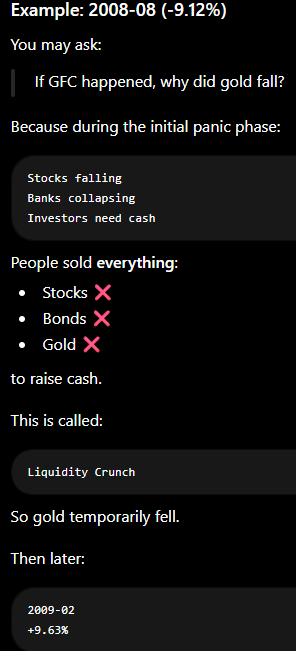

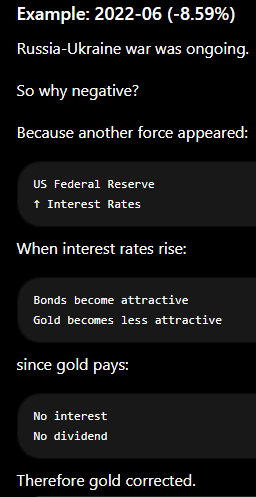

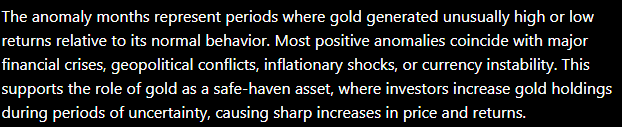

In [ ]:
event_analysis.to_excel(
    "Gold_Anomaly_Event_Analysis.xlsx",
    index=False
)

In [ ]:
events = {
    '2008-09':'GFC',
    '2011-08':'Euro Crisis',
    '2013-08':'Taper Tantrum',
    '2016-11':'Demonetization',
    '2020-03':'COVID',
    '2022-02':'Ukraine War',
    '2023-10':'Israel-Hamas',
    '2024-06':'Election'
}

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_master['Date'] = pd.to_datetime(df_master['Date'])

plt.figure(figsize=(18,7))

plt.plot(
    df_master['Date'],
    df_master['Gold_Price[/10gm]'],
    linewidth=2.5,
    color='gold'
)

for date,event in events.items():

    plt.axvline(
        pd.to_datetime(date),
        linestyle='--',
        alpha=0.7,
        color='red'
    )

    plt.text(
        pd.to_datetime(date),
        df_master['Gold_Price[/10gm]'].max()*0.85,
        event,
        rotation=90,
        fontsize=9
    )

plt.title(
    'Gold Price Behaviour Around Major Economic and Geopolitical Events (2000–2026)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Gold Price (₹ per 10gm)')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

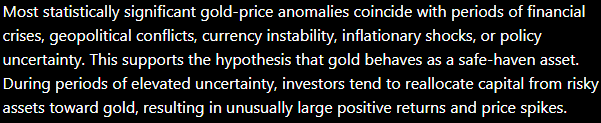

# **Gold During the Modern Crisis Era (2020–2026)**

In [ ]:
df_recent = df_master[
    (df_master['Date'] >= '2020-01')
].copy()

In [ ]:
df_recent

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    df_recent['Date'],
    df_recent['Gold_Price[/10gm]'],
    linewidth=3
)

plt.title(
    'Gold Price Trend (2020-2026)'
)

plt.ylabel('Gold Price (₹/10gm)')

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# %Growth
start_price = df_recent['Gold_Price[/10gm]'].iloc[0]

end_price = df_recent['Gold_Price[/10gm]'].iloc[-1]

growth = (
    (end_price-start_price)
    / start_price
)*100

print(growth)

In [ ]:
# %CAGR
years = 6

cagr = (
    (end_price/start_price)**(1/years)-1
)*100

print(cagr)

In [ ]:
#Monthly returns

df_recent['Return_%'] = (
    df_recent['Gold_Price[/10gm]']
    .pct_change()
    *100
)

In [ ]:
volatility = (
    df_recent['Return_%']
    .std()
)

print(volatility)

In [ ]:
full_vol = (
    df_master['Gold_Return_%']
    .std()
)

recent_vol = (
    df_recent['Return_%']
    .std()
)

In [ ]:
print(full_vol)
print(recent_vol)

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_recent['Return_%'],
    bins=15,
    kde=True
)

plt.title(
    'Distribution of Gold Returns (2020-2026)'
)

plt.show()

In [ ]:
df_recent['Rolling_Volatility'] = (
    df_recent['Return_%']
    .rolling(12)
    .std()
)

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    df_recent['Date'],
    df_recent['Rolling_Volatility']
)

plt.title(
    '12-Month Rolling Volatility'
)

plt.show()

In [ ]:
recent = df_master[
    df_master['Date'] >= '2020-01'
].copy()

recent['Year'] = (
    pd.to_datetime(recent['Date'])
    .dt.year
)

year_stats = []

for year,grp in recent.groupby('Year'):

    start = grp['Gold_Price[/10gm]'].iloc[0]
    end = grp['Gold_Price[/10gm]'].iloc[-1]

    yearly_return = (
        (end-start)/start
    )*100

    volatility = (
        grp['Gold_Return_%']
        .std()
    )

    year_stats.append({
        'Year':year,
        'Return_%':yearly_return,
        'Volatility_%':volatility,
        'Avg_Price':grp['Gold_Price[/10gm]'].mean()
    })

year_stats_df = pd.DataFrame(year_stats)

In [ ]:
recent = df_master[
    df_master['Date'] >= '2020-01'
].copy()

recent['Year'] = pd.to_datetime(
    recent['Date']
).dt.year

year_stats = []

for year, grp in recent.groupby('Year'):

    start_price = grp['Gold_Price[/10gm]'].iloc[0]
    end_price = grp['Gold_Price[/10gm]'].iloc[-1]

    annual_return = (
        (end_price - start_price)
        / start_price
    ) * 100

    annual_volatility = (
        grp['Gold_Return_%']
        .std()
    )

    year_stats.append({
        'Year': str(year),
        'Return_%': annual_return,
        'Volatility_%': annual_volatility
    })

year_stats_df = pd.DataFrame(year_stats)

year_stats_df

In [ ]:
plt.figure(figsize=(12,6))

colors = [
    '#4E79A7',
    '#F28E2B',
    '#59A14F',
    '#E15759',
    '#76B7B2',
    '#AF7AA1',
    '#EDC948'
]

bars = plt.bar(
    year_stats_df['Year'],
    year_stats_df['Return_%'],
    color=colors,
    edgecolor='black',
    linewidth=1
)

for bar in bars:

    h = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+1 if h>0 else h-2,
        f'{h:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.axhline(
    0,
    color='black',
    linewidth=1
)

plt.title(
    'Annual Gold Returns (2020–2026)',
    fontsize=18,
    fontweight='bold'
)

plt.ylabel('Return (%)')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    year_stats_df['Year'],
    year_stats_df['Volatility_%'],
    color='steelblue',
    edgecolor='black'
)

for bar in bars:

    h = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.1,
        f'{h:.1f}',
        ha='center',
        fontweight='bold'
    )

plt.title(
    'Annual Gold Volatility (2020–2026)',
    fontsize=18,
    fontweight='bold'
)

plt.ylabel('Volatility (%)')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    year_stats_df['Volatility_%'],
    year_stats_df['Return_%'],
    s=400,
    alpha=0.8
)

for _, row in year_stats_df.iterrows():

    plt.annotate(
        row['Year'],
        (
            row['Volatility_%'],
            row['Return_%']
        ),
        fontsize=11,
        fontweight='bold'
    )

plt.xlabel('Volatility (%)')
plt.ylabel('Return (%)')

plt.title(
    'Gold Risk vs Return (2020–2026)',
    fontsize=18,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.show()

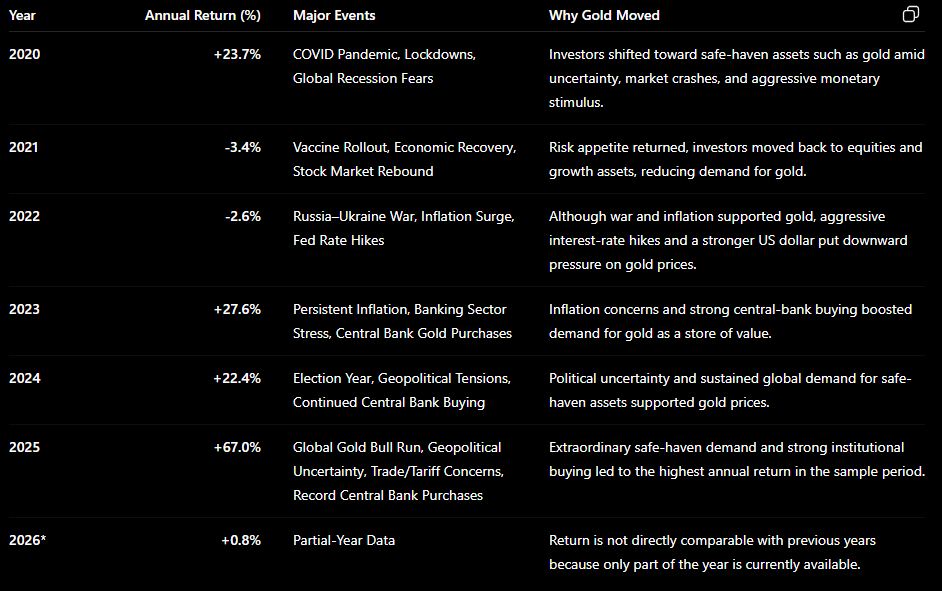

# **Missing Values Audit**

In [ ]:
df_master.isna().sum()

In [ ]:
(df_master == '---').sum()

# **Univariate Analysis**

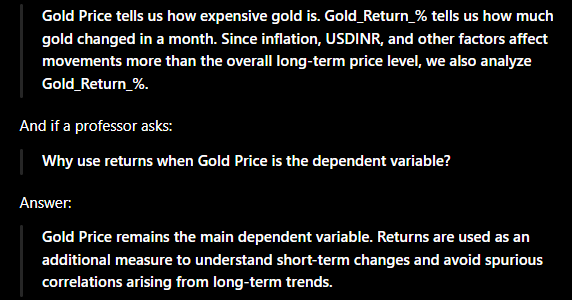
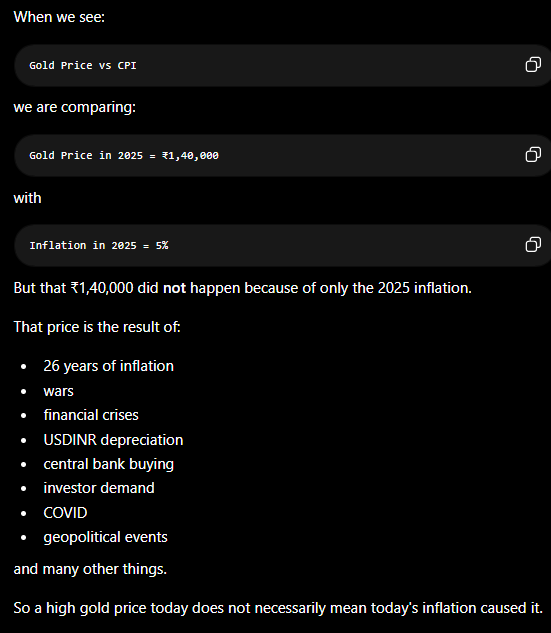
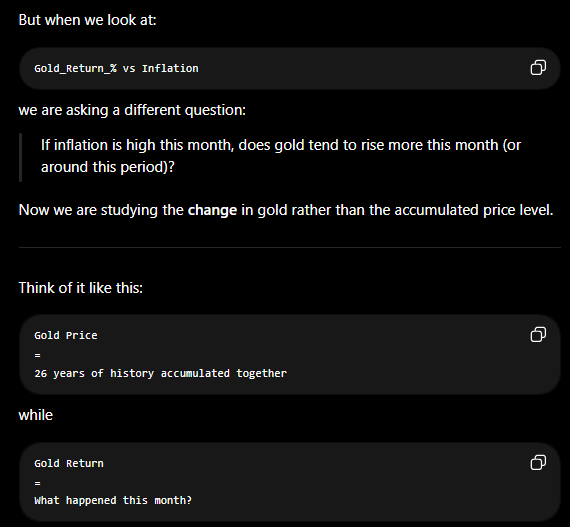

# **inflation YoY**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Date is datetime
df_master['Date'] = pd.to_datetime(df_master['Date'])

# Sort by date
df_master = df_master.sort_values('Date')

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_master,
    x='Date',
    y='Inflation_YoY',
    linewidth=2
)

plt.axhline(
    y=df_master['Inflation_YoY'].mean(),
    linestyle='--',
    color='red',
    label=f"Mean Inflation = {df_master['Inflation_YoY'].mean():.2f}%"
)

plt.title(
    'India Inflation (YoY) Trend: 2014–2026',
    fontsize=16,
    weight='bold'
)

plt.xlabel('Year')
plt.ylabel('Inflation YoY (%)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

df_master['Inflation_YoY'] = df_master['Inflation_YoY'].replace('---', np.nan).astype(float)
sns.histplot(
    df_master['Inflation_YoY']
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,3))

sns.boxplot(
    x=df_master['Inflation_YoY'],
    width=0.4,
    color='#4E79A7',
    linewidth=2,
    fliersize=6
)

plt.title(
    'Distribution of Inflation Rate (YoY)',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Inflation Rate (%)',
    fontsize=12
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [ ]:
q1 = df_master['Inflation_YoY'].quantile(0.25)
median = df_master['Inflation_YoY'].median()
q3 = df_master['Inflation_YoY'].quantile(0.75)

print(q1, median, q3)

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_master,
    x='Inflation_YoY',
    y='Gold_Price[/10gm]',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title(
    'Gold Price vs Inflation',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Inflation YoY (%)')
plt.ylabel('Gold Price (₹/10gm)')

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_master,
    x='Inflation_YoY',
    y='Gold_Return_%',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'orange'}
)

plt.title(
    'Gold_Return_% vs Inflation',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Inflation YoY (%)')
plt.ylabel('Gold_Return_%')

plt.show()

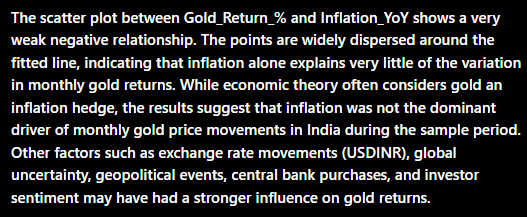

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Replace '---' with NaN and convert to float for 'Inflation_MoM'
df_master['Inflation_MoM'] = df_master['Inflation_MoM'].replace('---', np.nan).astype(float)

# Remove missing values
df_inf = df_master[
    ['Gold_Return_%', 'Inflation_MoM']
].dropna()

# Correlation
corr = df_inf.corr().iloc[0,1]

# Plot
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_inf,
    x='Inflation_MoM',
    y='Gold_Return_%',
    scatter_kws={'alpha':0.7},
    line_kws={'linewidth':2}
)

plt.text(
    0.05,
    0.95,
    f'Correlation = {corr:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white')
)

plt.title(
    'Gold Returns vs Inflation (MoM)',
    fontsize=14,
    weight='bold'
)

plt.xlabel('Inflation MoM (%)')
plt.ylabel('Gold Return (%)')

plt.grid(alpha=0.3)

plt.show()

print(f"Correlation = {corr:.3f}")

In [ ]:
df_master[
    ['Gold_Return_%','Inflation_YoY']
].corr()

In [ ]:
df_master[
    ['Gold_Price[/10gm]','Inflation_YoY']
].corr()

# **USDINR**

In [ ]:
#USDINR
sns.histplot(df_master['USDINR'], kde=True)

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df_master['Date'],
    df_master['USDINR']
)

plt.title('USDINR Exchange Rate (2000–2026)')
plt.xlabel('Year')
plt.ylabel('USD/INR')
plt.grid(alpha=0.3)

plt.show()

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df_master['USDINR']
)

plt.title('USDINR Boxplot')
plt.show()

In [ ]:
df_master['USDINR'].describe()

In [ ]:
events = {
    '2008-09':'GFC',
    '2013-08':'Taper Tantrum',
    '2016-11':'Demonetization',
    '2020-03':'COVID',
    '2022-02':'Ukraine War'
}

plt.figure(figsize=(16,6))

plt.plot(
    pd.to_datetime(df_master['Date']),
    df_master['USDINR'],
    linewidth=2.5,
    color='darkblue'
)

for date,label in events.items():

    plt.axvline(
        pd.to_datetime(date),
        color='red',
        linestyle='--',
        alpha=0.6
    )

    plt.text(
        pd.to_datetime(date),
        df_master['USDINR'].max()*0.95,
        label,
        rotation=90
    )

plt.title(
    'USDINR Movement with Major Economic Events',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('USDINR')

plt.grid(alpha=0.3)

plt.show()

In [ ]:
pre = df_master[
    (df_master['Date'] >= '2000-01')
    & (df_master['Date'] < '2020-01')
]

post = df_master[
    df_master['Date'] >= '2020-01'
]

comparison = pd.DataFrame({
    'Mean':[pre['USDINR'].mean(),
            post['USDINR'].mean()],
    'Std':[pre['USDINR'].std(),
           post['USDINR'].std()],
    'Min':[pre['USDINR'].min(),
           post['USDINR'].min()],
    'Max':[pre['USDINR'].max(),
           post['USDINR'].max()]
},
index=['2000-2019','2020-2026'])

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    comparison.index,
    comparison['Mean'],
    color=['#4E79A7','#E15759'],
    edgecolor='black'
)

for bar in bars:

    h = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.5,
        f'{h:.2f}',
        ha='center',
        fontweight='bold'
    )

plt.title(
    'Average USDINR: Pre-COVID vs Post-COVID',
    fontsize=15,
    fontweight='bold'
)

plt.ylabel('Average USDINR')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

for i, period in enumerate(comparison.index):

    plt.plot(
        [i,i],
        [comparison.loc[period,'Min'],
         comparison.loc[period,'Max']],
        linewidth=8,
        alpha=0.7
    )

    plt.scatter(
        i,
        comparison.loc[period,'Mean'],
        s=200,
        color='red',
        zorder=5,
        label='Mean' if i==0 else ""
    )

plt.xticks(
    [0,1],
    comparison.index
)

plt.ylabel('USDINR')

plt.title(
    'USDINR Range Comparison\n(Mean shown as Red Dot)',
    fontsize=15,
    fontweight='bold'
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_master,
    x='USDINR',
    y='Gold_Price[/10gm]'
)

plt.title('Gold Price vs USDINR')
plt.show()

In [ ]:
df_master[
    ['Gold_Price[/10gm]','USDINR']
].corr()

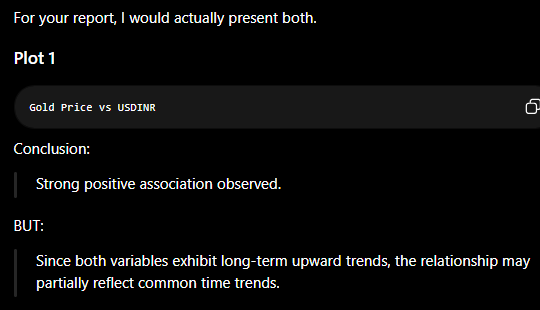

In [ ]:
# Monthly USDINR returns (%)

df_master['USDINR_Return_%'] = (
    df_master['USDINR']
    .pct_change()
    * 100
)

# Check
df_master[['Date','USDINR','USDINR_Return_%']].head()

In [ ]:
df_returns = df_master[
    ['Gold_Return_%', 'USDINR_Return_%']
].dropna()

In [ ]:
corr = df_returns.corr().iloc[0,1]

print(f"Correlation = {corr:.3f}")

In [ ]:
corr = df_returns.corr().iloc[0,1]

plt.figure(figsize=(8,6))

sns.regplot(
    data=df_returns,
    x='USDINR_Return_%',
    y='Gold_Return_%',
    scatter_kws={'alpha':0.7},
    line_kws={'linewidth':2}
)

plt.text(
    0.05,
    0.95,
    f'Correlation = {corr:.3f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white')
)

plt.title(
    'Gold Returns vs USDINR Returns',
    fontsize=14,
    weight='bold'
)

plt.xlabel('USDINR Return (%)')
plt.ylabel('Gold Return (%)')

plt.grid(alpha=0.3)

plt.show()

# **Repo Rate**